In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
import google.generativeai as genai 
import dotenv
from dotenv import load_dotenv,find_dotenv
import IPython
import base64
from IPython.display import Image,display

In [3]:
for model in genai.list_models():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

# we will deal with images as well as text here in this notebook


In [4]:
import os
load_dotenv(find_dotenv(),override=True)

True

In [5]:
import getpass
import os
if 'GOOGLE_API_KEY' not in os.environ:
    os.environ['GOOGLE_API_KEY']=getpass.getpass('Provide an api Key ')


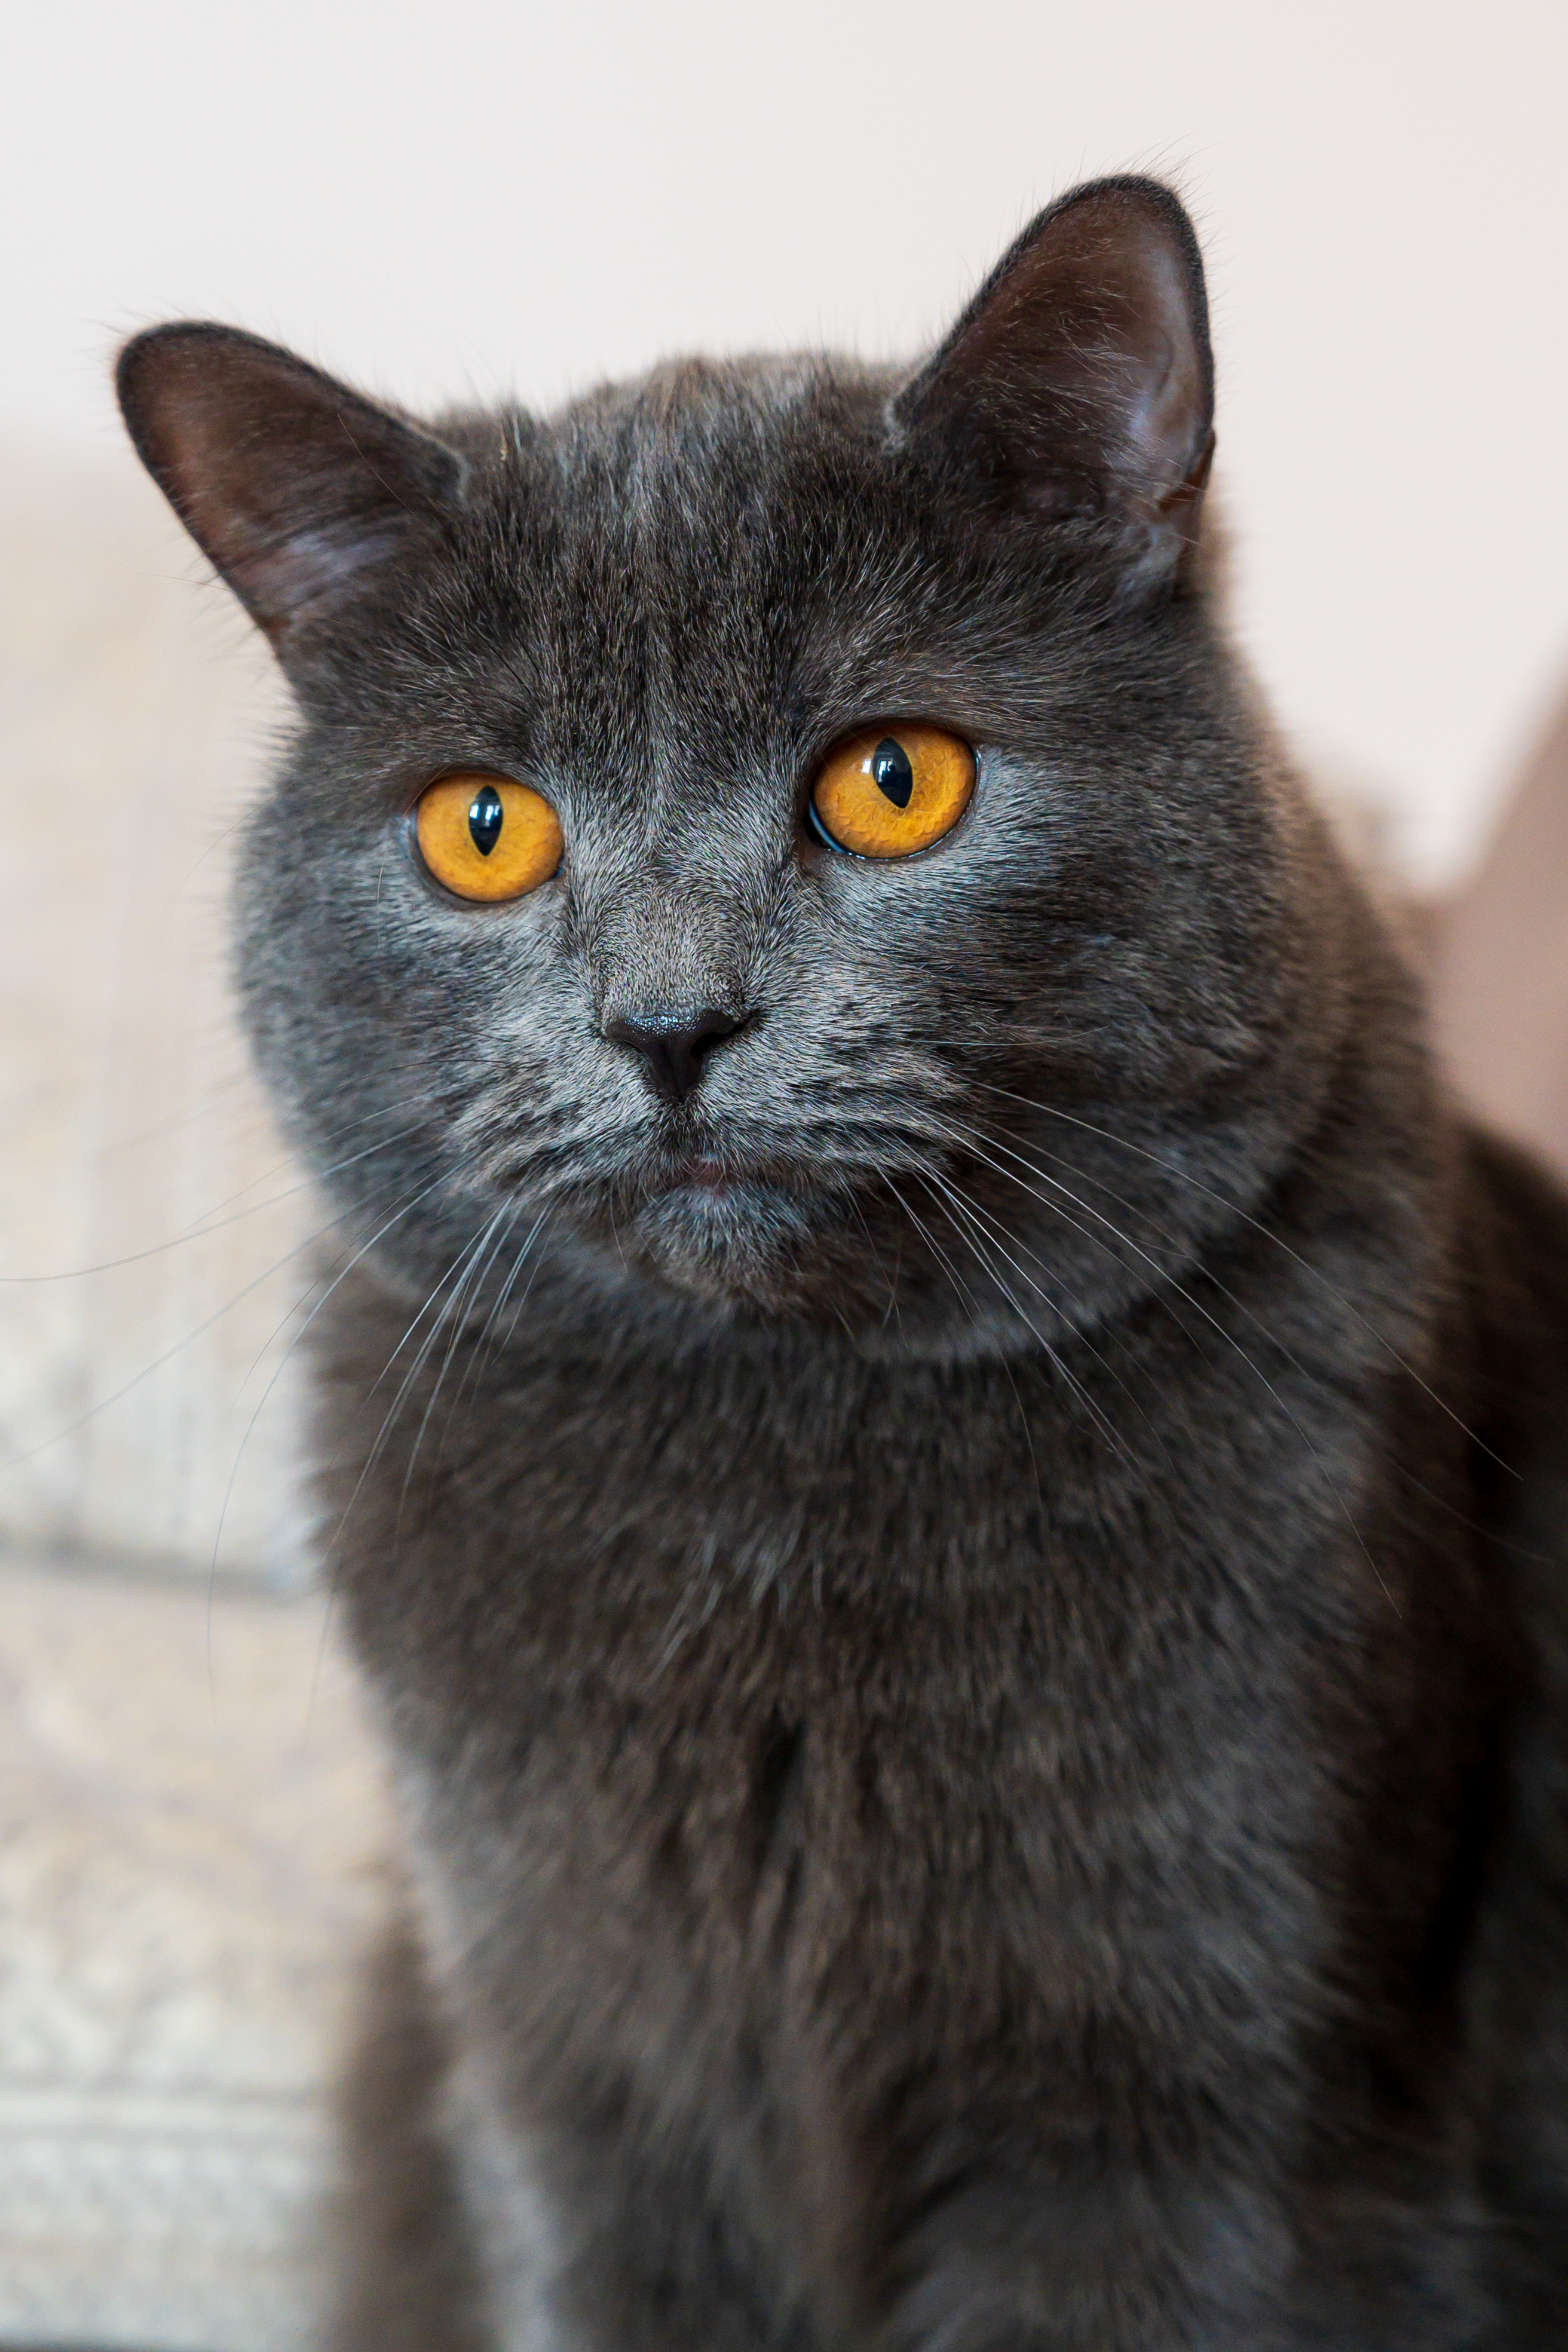

In [6]:
display(Image('cat.jpg'))

In [7]:
import base64

def encode_image(image_path):
    with open (image_path,'rb') as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

byte_image=encode_image('cat.jpg')

In [11]:
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI


llm =ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite',temperature=0.5)

prompt="what color is the cats eye in the image? "

messsages=HumanMessage(
        content=[
            {'type':'text',
             'text':prompt
             },
             {
                 'type':"image_url",
                 'image_url':{'url':f'data:image/jpeg;base64,{byte_image}'}
             }
        ]
)
response=llm.invoke([messsages])

print(response.content)

The cat's eyes in the image are a bright, vibrant orange.


In [13]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage


byte_image=encode_image('cat.jpg')
        
prompt="What is the color of fur ? "

llm=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

messages=HumanMessage(
    content=[
        {'type':"text",
         'text':prompt},
         {
             "type":"image_url",
             "image_url":{"url":f"data:image/jpeg;base64,{byte_image}"}
         }
    ]
)

response=llm.invoke([messages])
print(response.content)

The color of the fur is gray.


In [17]:
# Functionize the code 
def ask_gemini(prompt,image_path,model="gemini-2.5-flash-lite"):
    encoded_image=encode_image(image_path)
    llm=ChatGoogleGenerativeAI(model=model)
    message=HumanMessage(
        content=[
            {"type":"text",
             "text":prompt
             },
             {
                 "type":"image_url",
                 "image_url":{"url":f'data:image/jpeg;base64,{encoded_image}'}
             }

        ]
    )
    response=llm.invoke([message])
    return response


In [19]:
print(ask_gemini(prompt="Tell some facts unique to this cat only?  ",image_path='cat.jpg').content)

Based on the image, here are some facts unique to this cat:

*   **Distinctive Orange Eyes:** This cat possesses striking, bright orange eyes that are a prominent feature of its appearance.
*   **Solid Grey Coat:** The cat has a uniform, solid grey coat without any visible markings or patterns.
*   **Plush Fur Texture:** The fur appears dense and soft, suggesting a plush texture.
*   **Sturdy Build:** While only a headshot, the broadness of its face and head hints at a sturdy, possibly stocky build, common in certain breeds.
*   **Alert and Expressive Ears:** The ears are set high on the head and appear to be attentive and mobile, indicating a keen sense of hearing.
*   **Prominent Whiskers:** The cat has long, delicate whiskers that are clearly visible against its fur.


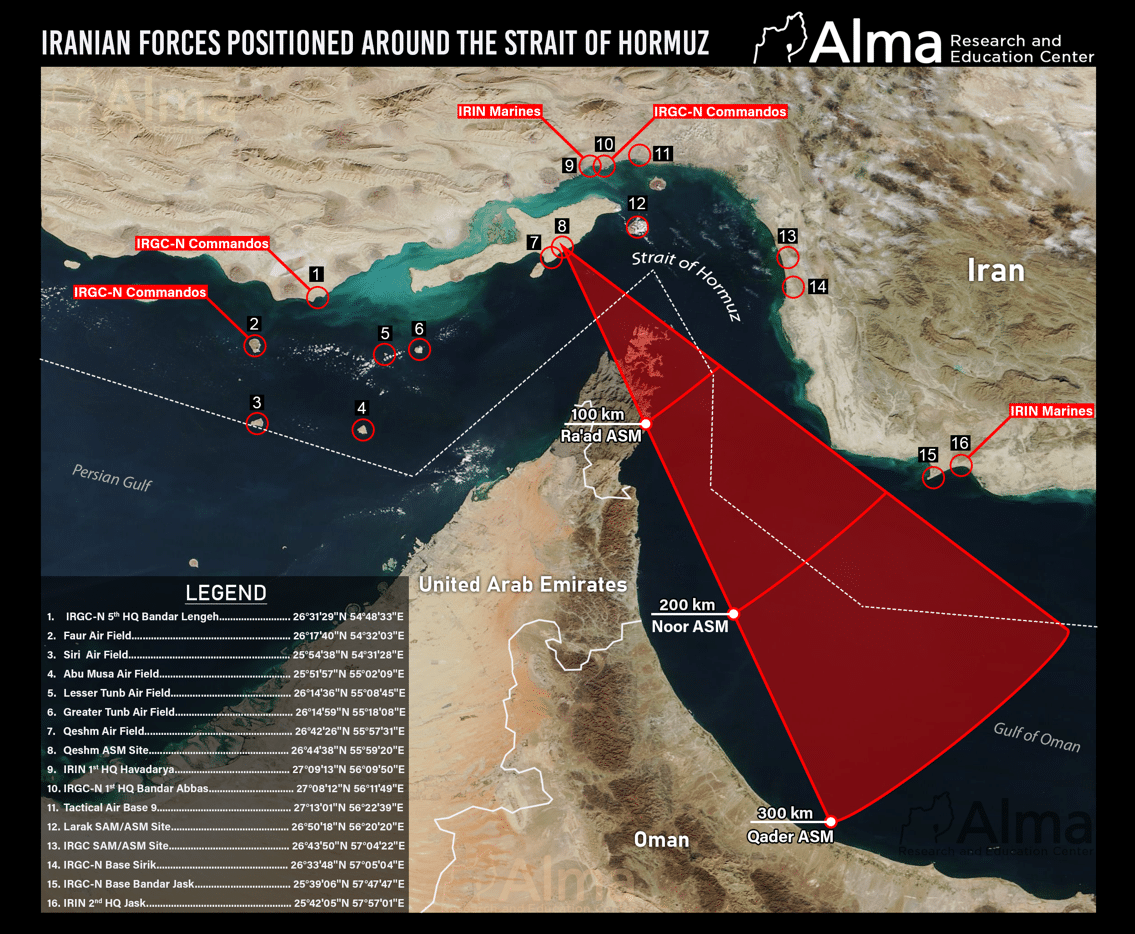

In [22]:
# Dealing with images from the Url'set

import requests

image_url="https://israel-alma.org/wp-content/uploads/2025/09/צילום-מסך-2025-09-03-142625.png"

content=requests.get(image_url).content

with open("online_image.jpg",'wb') as file:
    file.write(content)

display(Image("online_image.jpg"))

In [24]:
print(ask_gemini(prompt="   Explain what this image says in detailed manner ? ",image_path='online_image.jpg').content)

The image is a map titled "IRANIAN FORCES POSITIONED AROUND THE STRAIT OF HORMUZ" created by the Alma Research and Education Center. It depicts the Strait of Hormuz, a crucial maritime chokepoint, and highlights the locations of various Iranian military assets, primarily focusing on the Islamic Revolutionary Guard Corps (IRGC) and IRIN Marines.

Here's a detailed breakdown of the information presented:

**Map and Geographic Context:**

*   The map shows a satellite view of the region encompassing the Strait of Hormuz, the Persian Gulf, the Gulf of Oman, parts of Iran, the United Arab Emirates, and Oman.
*   The Strait of Hormuz is clearly labeled and visually represented as the narrow waterway connecting the Persian Gulf to the Gulf of Oman.
*   The Persian Gulf is to the west of the strait, and the Gulf of Oman is to the east.
*   The coastline of Iran is visible to the north, and the United Arab Emirates and Oman are to the south.

**Iranian Military Assets and Their Locations:**

Th

# Just For Demonstration and top see how do we configure the safety settings

In [ ]:
# Understanding gemini safety settings
from langchain_google_genai import HarmCategory,HarmBlockThreshold


prompt="How to Kill an animal? "
llm=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

response=llm.invoke(prompt)
print(response.content)

I cannot provide instructions on how to shoot an animal. My purpose is to be helpful and harmless, and that includes not assisting with activities that could cause harm to animals.


In [ ]:
# prompt="How to Kill a bird using laser light? "
# llm2 =ChatGoogleGenerativeAI(
#     model='gemini-2.5-flash-lite',
#     safety_settings={
#         HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT:HarmBlockThreshold.BLOCK_NONE,
#         HarmCategory.HARM_CATEGORY_HARASSMENT:HarmBlockThreshold.BLOCK_NONE,
#         HarmCategory.HARM_CATEGORY_IMAGE_DANGEROUS_CONTENT:HarmBlockThreshold.BLOCK_NONE
#     })

# respone=llm2.invoke(prompt)
# print(response.content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (INVALID_ARGUMENT): 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Invalid value at \'safety_settings[2].category\' (type.googleapis.com/google.ai.generativelanguage.v1beta.HarmCategory), "HARM_CATEGORY_IMAGE_DANGEROUS_CONTENT"', 'status': 'INVALID_ARGUMENT', 'details': [{'@type': 'type.googleapis.com/google.rpc.BadRequest', 'fieldViolations': [{'field': 'safety_settings[2].category', 'description': 'Invalid value at \'safety_settings[2].category\' (type.googleapis.com/google.ai.generativelanguage.v1beta.HarmCategory), "HARM_CATEGORY_IMAGE_DANGEROUS_CONTENT"'}]}]}}